# Lab 02-1 - Hierarchical Clustering

In this lab we will transition towards focusing on machine learning methods themselves and away from the inner working of Python, `numpy`, and `pandas`. You should be prepared to use information from previous labs, but also to use published documentation to learn about useful functions, methods, and attributes on your own.

In [53]:
## Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Examples throughout the lab will use the "moons" and "blobs" toy data sets that were introduced in a previous lab:

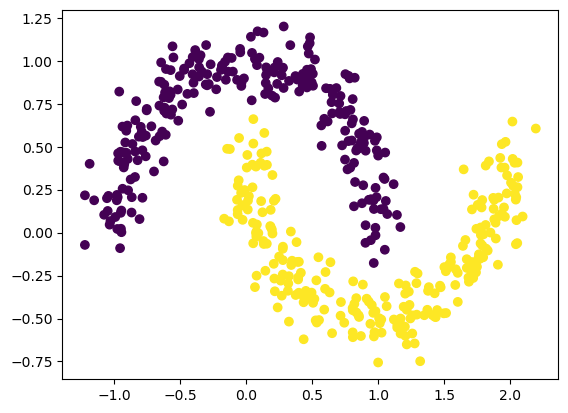

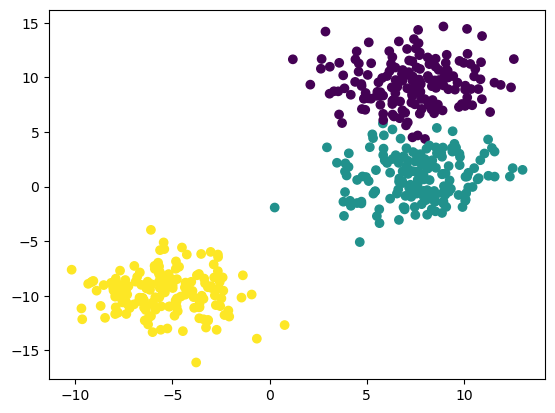

In [54]:
## Datasets module
from sklearn import datasets

## Toy Dataset #1 - "moons"
moons = datasets.make_moons(n_samples=500, noise=0.11, random_state=8)
moons_X = moons[0]         # features to use in clustering
moons_labels = moons[1]    # true cluster identities

## Visualization
plt.scatter(moons_X[:,0], moons_X[:,1], c = moons_labels)
plt.show()

## Toy Dataset #2 - "blobs"
blobs = datasets.make_blobs(n_samples=500, cluster_std=2, random_state=8)
blobs_X = blobs[0]         # features to use in clustering
blobs_labels = blobs[1]    # true cluster identities

## Visualization
plt.scatter(blobs_X[:,0], blobs_X[:,1], c = blobs_labels)
plt.show()

## Part 1 - Agglomerative clustering

### Model Fitting and Dendrograms

Agglomerative clustering is implemented in the `cluster` module of `sklearn`. The basic workflow of many models implemented in sklearn is to first initialize a model then fit to your data using its `.fit()` method below. The arguments `distance_threshold=0` and `n_clusters=None` are used to ensure that the full dendrogram is fit to the data.

In [55]:
from sklearn.cluster import AgglomerativeClustering
agg_cluster_single = AgglomerativeClustering(
    linkage = 'single', 
    distance_threshold=0, 
    n_clusters=None).fit(moons_X)

Unfortunately there not currently an official function to plot dendrograms in `sklearn`, but the following function, which is [described here](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html), can be used to create a basic dendrogram. Don't concern yourself too much with understanding how this code works; rather take it as given.

In [56]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

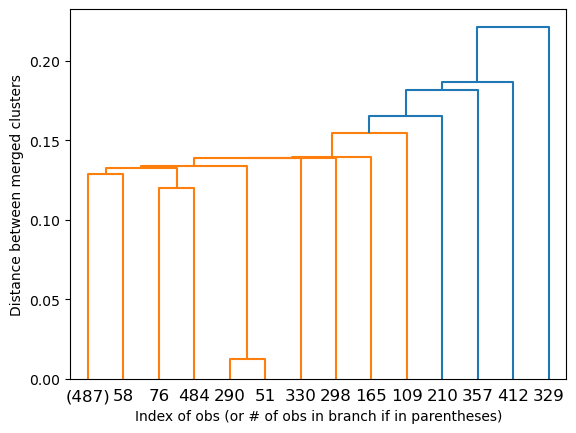

In [57]:
## Part of the dendrogram for "moons"

# The p argument sets how deep down the dendrogram tree should we plot.
# Try different values and see how the numbers in parentheses change
plot_dendrogram(model = agg_cluster_single, truncate_mode="level", p=10) 
plt.xlabel("Index of obs (or # of obs in branch if in parentheses)")
plt.ylabel("Distance between merged clusters")
plt.show()

A few things you should notice in this example:

1. The function relies upon the `dendogram()` function in the `scipy` library. This function is assigning colors to the branches of the dendrogram via its default arguments. You can [read more here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html#scipy.cluster.hierarchy.dendrogram). 
1. Along the x-axis of the dendrogram:
    1. numbers without parentheses are the index positions (row numbers) of invidual observations (row numbers)
    1. numbers appearing in parentheses indicate the number of observations in that branch
1. We used the single linkage criterion, which is what causes the "chaining" behavior that can be seen in this subsection of the dendrogram (notably on the right side of the graph where samples are merged into the cluster one by one)

Let's see what the fitted clusters actually look like. For this, we need to apply the `.fit_predict()` method to apply our cluster model to the `moons_X` data. This will give us the label of the cluster that each observation is assigned to. For example, the first observation is assigned to a cluster labeled `485`.Notice we have a lot of unique values i.e. a lot of unique resulting clusters.

In [58]:
agg_cluster_single_predicted = AgglomerativeClustering(
    linkage = 'single', 
    distance_threshold=0, 
    n_clusters=None).fit_predict(moons_X)
agg_cluster_single_predicted

array([485, 430, 273, 487, 398, 278, 443, 383, 489, 439, 437, 373, 362,
       449, 290, 435, 479, 495, 499, 288, 367, 403, 397, 318, 429, 434,
       455, 407, 379, 319, 344, 310, 336, 444, 375, 469, 431, 359, 451,
       270, 333, 448, 377, 349, 346, 258, 266, 471, 438, 361, 368, 315,
       300, 221, 408, 299, 321, 312, 351, 391, 180, 481, 307, 314, 452,
       320, 395, 360, 411, 356, 322, 331, 345, 450, 460, 347, 415, 382,
       298, 421, 402, 265, 474, 262, 412, 488, 218, 483, 493, 417, 473,
       384, 413, 381, 343, 498, 440, 404, 183, 486, 243, 353, 172, 400,
       467, 271, 389, 457, 374, 191, 205, 472, 409, 419, 284, 461, 267,
       365, 292, 219, 371, 285, 160, 159, 445, 341, 283, 380, 179, 484,
       269, 253, 256, 309, 282, 458, 241, 418, 480, 335, 316, 420, 239,
       453, 350, 476, 427,  89, 396, 328, 463, 214, 190, 355, 447, 254,
       317, 209, 268, 223, 358, 410, 332, 303, 324, 465, 264, 186, 376,
       287, 304, 462, 325, 143, 295, 230, 279, 416, 414, 387, 16

Let's plot these clusters where we set `c` color to be the cluster labels. Again, we see a lot of unique clusters.

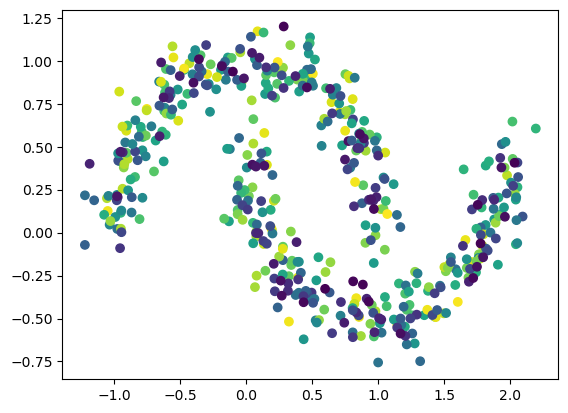

In [59]:
plt.scatter(moons_X[:,0], moons_X[:,1], c = agg_cluster_single_predicted) 
plt.show()

**Question 1**:

- **Part A**: Apply agglomerative clustering using ward linkage to the "moons" data set. Display the first 10 levels of the resulting dendrogram.
- **Part B**: How does this dendrogram compare to the example that used single linkage? Highlight any noticeable differences you see and what they say about the nature of the resulting clusters.
- **Part C**: Plot the observations' cluster labels. What do you notice different?

In [60]:
#agglomerative clustering with ward linkage on the "moons" dataset
agg_cluster_ward = AgglomerativeClustering(
    linkage = 'ward', 
    distance_threshold=0, 
    n_clusters=None).fit(moons_X)

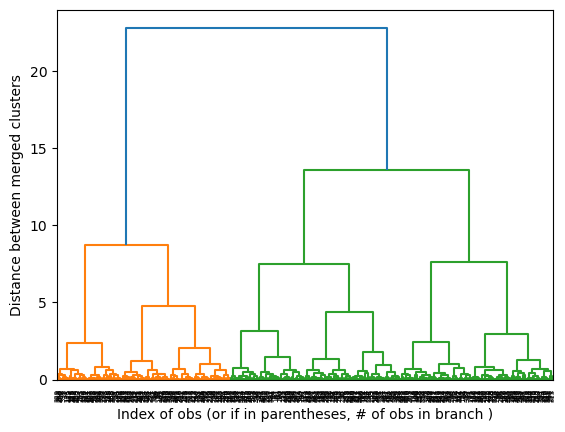

In [61]:
plot_dendrogram(model = agg_cluster_ward, truncate_mode="level", p= 10) 
plt.xlabel("Index of obs (or if in parentheses, # of obs in branch )")
plt.ylabel("Distance between merged clusters")
plt.show()

The range of the distance between clusters merged using ward clustering is much larger than the distance between clusters merged using single clustering. For the same depth down the dendogram plot(p=10), the clusters merged using ward clustering are more compact than the ones merged using single linkage. Ward linkage prioritizes merging clusters that will cause the smallest increase in the total within cluster variance. Early on, clusters are small and the points are closely spaced so each merge causes a small increase in total within cluster variance, plotted on the y axis. However, as clusters become bigger, merging two clusters causes a much larger increase in total within cluster variance hence the height value increases sharply near the top of the dendrogram. Single linkage on the other hand finds the minimum distance between points in different clusters and merges them. The moons data set has the data points clustered along a crescent shape at roughly uniform density, so the nearest unmerged neighbor is never far away. Therefore, when clustering neighboring points, the distance between the single closest points stays relatively small and grows much slower since you are basically just linking neighboring points all the way up the dendrogram.

In [62]:
agg_cluster_ward_predicted= AgglomerativeClustering(
    linkage = 'ward',
    distance_threshold =0,
    n_clusters =None).fit_predict(moons_X)
agg_cluster_ward_predicted


array([486, 440, 389, 357, 421, 390, 449, 347, 353, 447, 444, 366, 403,
       267, 340, 499, 435, 287, 249, 339, 387, 424, 305, 293, 451, 392,
       460, 426, 479, 414, 450, 294, 465, 260, 348, 373, 265, 422, 322,
       279, 367, 454, 328, 380, 377, 325, 256, 423, 445, 352, 394, 477,
       350, 425, 455, 368, 483, 409, 495, 345, 395, 314, 264, 431, 456,
       364, 418, 385, 299, 384, 472, 492, 354, 227, 464, 378, 309, 416,
       330, 487, 396, 194, 476, 386, 436, 269, 288, 410, 379, 361, 469,
       406, 324, 270, 313, 498, 429, 404, 393, 371, 474, 321, 320, 365,
       250, 333, 303, 461, 334, 311, 497, 442, 319, 496, 248, 285, 280,
       286, 342, 468, 262, 441, 363, 448, 326, 475, 188, 323, 142, 268,
       272, 275, 484, 192, 290, 263, 402, 401, 432, 369, 399, 370, 481,
       397, 283, 478, 473, 181, 419, 182, 482, 439, 201, 480, 453, 224,
       446, 215, 196, 471, 407, 223, 375, 391, 204, 355, 383, 344, 346,
       427, 297, 239, 408, 463, 358, 434, 255, 278, 310, 195, 27

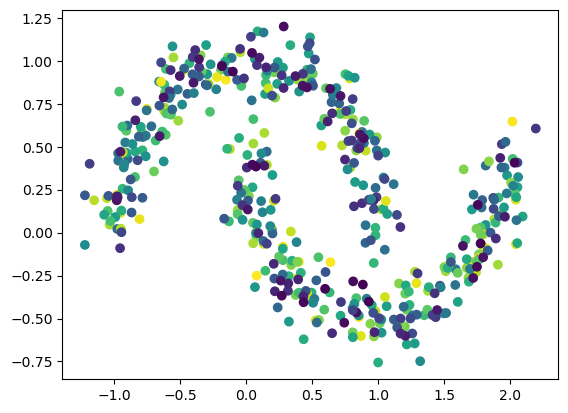

In [63]:
plt.scatter(moons_X[:,0], moons_X[:,1], c=agg_cluster_ward_predicted)
plt.show()

I did not observe any difference between the two plots. Regardless of linkage type, when the number of clusters specified in the code is zero and the distance threshold is 0, no meaningful groupings are formed and in fact because coordinates rarely fall in the same exact point, every data point becomes its own unique cluster label. Plotting this, results in no meanigful difference between the  ward linkage and single linkage plots. 

To introduce a difference, I set the distance_threshold to None and compare the two linkages at n_clusters = 5. 

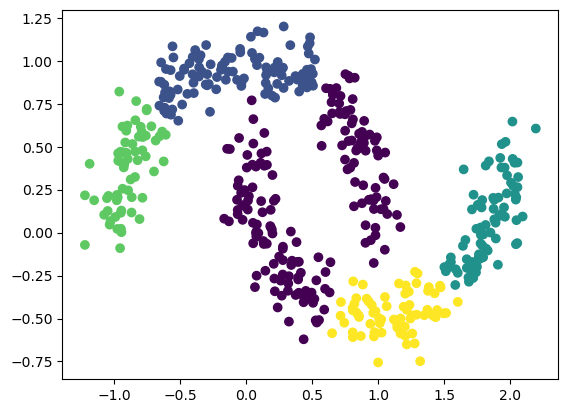

In [64]:
agg_cluster_ward_predicted_5= AgglomerativeClustering(
    linkage = 'ward',
    n_clusters = 5).fit_predict(moons_X)
agg_cluster_ward_predicted_5
plt.scatter(moons_X[:,0],moons_X[:,1],c=agg_cluster_ward_predicted_5)
plt.show()

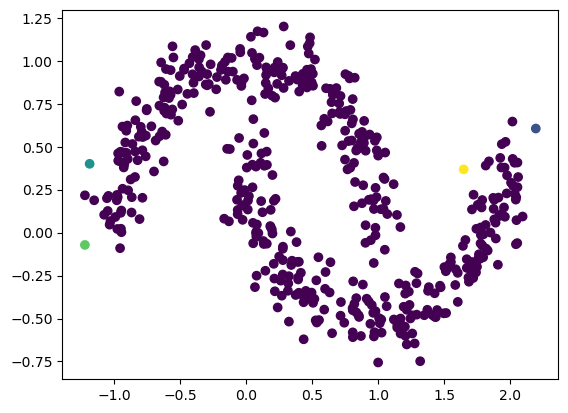

In [65]:
agg_cluster_single_predicted_5= AgglomerativeClustering(
    linkage = 'single',
    n_clusters = 5).fit_predict(moons_X)
agg_cluster_single_predicted_5
plt.scatter(moons_X[:,0],moons_X[:,1],c=agg_cluster_single_predicted_5)
plt.show()

The Single linkage plot reveals groups consisting of two crescents(grouped together) and 4 lone points. This points to the chaining property of how single linkage forms clusters. Single linkage merges whichever two clusters have the closest pair of points. Whatever point happens to be sitting farther from their nearest neighbor than the typical point in the chain is isolated as its own single point rather than get folded into the grouping.

This contrasts the Ward linkage plot, where there are 5 meaningfully distinct groupings along the crescent. Since grouping is based on minimizing increase in the within cluster variance, absorbing a stray point into an existing cluster results in less variance within the cluster than merging two substantial clusters. Ward linkage ends up folding in outliers into clusters early on while Single linkage prioritizes the closest pair of points resulting in groupings consisting of a chain of neighboring points and single outliers

### Cluster Labels

It is possible to "cut" a hierarchical clustering model to obtain a set $k$ non-overlapping clusters.

This practice allows us to compare the performance of hierarchical methods to alternatives like $k$-means, at least when we know the true clusters like we do in the simulated "moons" and "blobs" examples. In real-world applications, we must use our own judgement to decide if a clustering algorithm is producing useful and appropriate results.

The number of clusters can be chosen based upon context of the application, or inspection of the dendrogram to find a location where the height differences between merges begins to become large (an approach analogous to the "elbow" approach in 
$k$-means).

Below we refit our single linkage agglomerative clustering using $k=3$ and display the results. In order to plot the results, we use the `fit_predict()` method to get the predicted cluster labels for the given data:

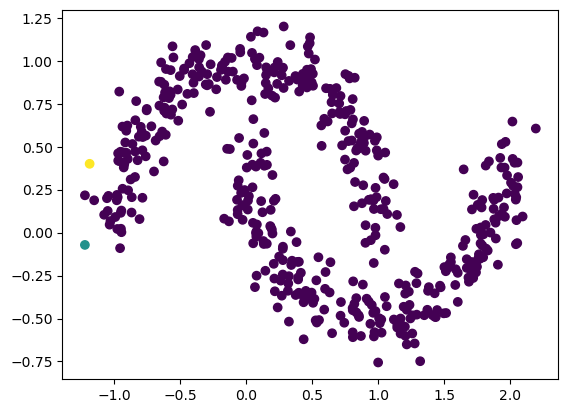

In [66]:
agg_cluster_single_3 = AgglomerativeClustering(
    linkage = 'single', 
    n_clusters=3).fit_predict(moons_X)
plt.scatter(moons_X[:,0], moons_X[:,1], c = agg_cluster_single_3) 
plt.show()

In this example we see the failure of the single linkage method. Other linkage criteria, such as 'complete' tend to perform a little better but not great:

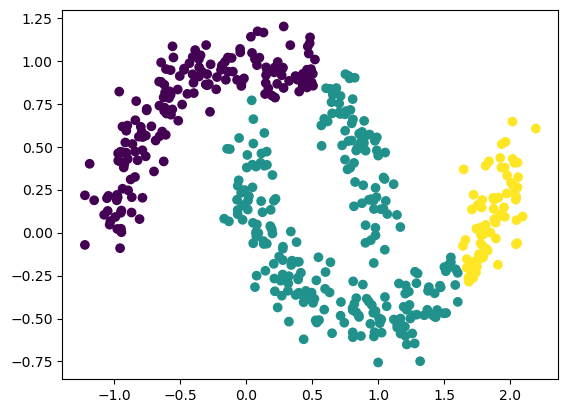

In [67]:
agg_cl_complete_3 = AgglomerativeClustering(
    linkage = 'complete', 
    n_clusters=3).fit_predict(moons_X)
plt.scatter(moons_X[:,0], moons_X[:,1], c = agg_cl_complete_3) 
plt.show()

You might also have noticed that we did not standardize our features, so these clusters might be disproportionately influenced by our first feature (shown on the x-axis). Unfortunately, standardization isn't enough to yield the results we desire:

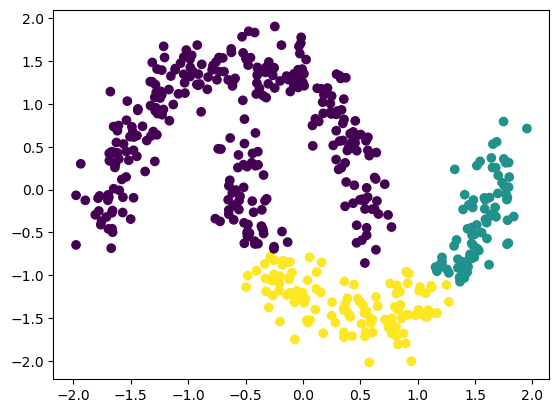

In [68]:
from sklearn.preprocessing import StandardScaler
moons_XS = StandardScaler().fit_transform(moons_X) 

agg_cl_complete_3 = AgglomerativeClustering(
    linkage = 'complete', 
    n_clusters=3).fit_predict(moons_XS)
plt.scatter(moons_XS[:,0], moons_XS[:,1], c = agg_cl_complete_3) 
plt.show()

**Question 2**:

- **Part A**: Analyze the "blobs" data set using agglomerative clustering to obtain $k=3$ clusters. Use scatter plots and your own judgements to decide upon an acceptable linkage criterion. Display a scatter plot showing cluster label assignments of your choice. Standardize the data before you begin your analysis.
- **Part B**: Analyze the "blobs" data set using $k$-means clustering to obtain $k=3$ clusters. Display a scatter plot showing cluster label assignments of your choice. Standardize the data before you begin your analysis.
- **Part C**: Comment on any differences. Which method to you prefer and why?

In [69]:
blobs_XS = StandardScaler().fit_transform(blobs_X)

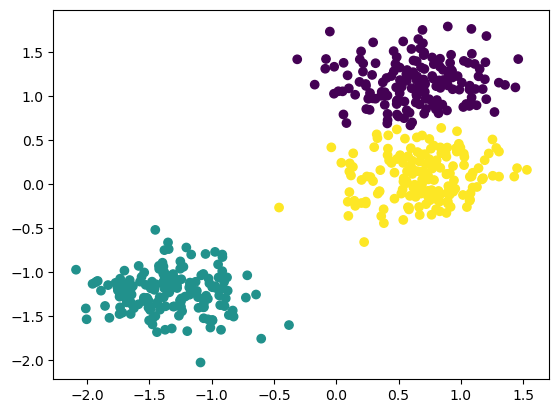

In [70]:
blob_agg_cluster_ward__3 = AgglomerativeClustering(
    linkage = 'ward',
    n_clusters =3).fit_predict(blobs_XS)
plt.scatter(blobs_XS[:,0],blobs_XS[:,1],c = blob_agg_cluster_ward__3)
plt.show()

In [71]:
from sklearn.cluster import KMeans # Import k-means function
import warnings
warnings.filterwarnings("ignore") ## We will turn off warnings since k-means will warn about future changes

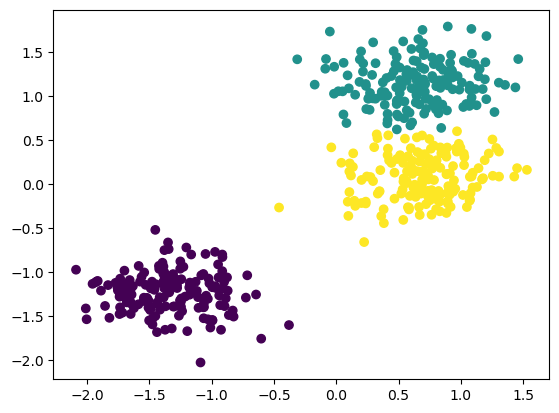

In [72]:
blobs_cluster_3 = KMeans(n_clusters = 3,random_state =8).fit_predict(blobs_XS)
plt.scatter(blobs_XS[:,0],blobs_XS[:,1],c = blobs_cluster_3)
plt.show()

There weren't any significant differences between the two plots. However, I noticed that the coloring of the different clusters was different. A possible explanation for this is that cluster label numbers are arbitrary so the cluster colors and numbers will be different for different methods.

All things considered, Kmeans clustering and Ward linkage use the same underlying principle to cluster points i.e clusters that minimize within-cluster variance. It is therefore expected that their results will converge.

Although Agglomerative clustering has a high computational burden, I prefer it to Kmeans clustering because it does not require random initialization. While Kmeans works perfectly for the blob dataset, wrong random initialization for a noisier data set might produce a final result where one real group is split in two and merge two different groups.